In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import os
import ssl
from glob import glob
import random

import torchvision.transforms.functional as F

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json
from concurrent.futures import ThreadPoolExecutor

## kiểm tra cuda

In [2]:
print("Có GPU không? :", torch.cuda.is_available())  # Phải trả về True
print("Phiên bản CUDA trong PyTorch:", torch.version.cuda)
print("Tên GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Không có GPU")

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng: {device}") # phải là: Đang sử dụng: cuda

Có GPU không? : True
Phiên bản CUDA trong PyTorch: 11.8
Tên GPU: GRID P40-24Q
Đang sử dụng: cuda


## load dữ liệu và chia ngẫu nhiên theo tỉ lệ 90:5:5

In [3]:
# Định nghĩa đường dẫn thư mục chứa dữ liệu
data_dir = "data/images"
train_data, valid_data, test_data = [], [], []
label_map = {}  # Mapping nhãn -> số


for label_idx, label in enumerate(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)
    if not os.path.isdir(label_path):
        continue
    
    # Lưu ánh xạ nhãn
    label_map[label] = label_idx
    
    # Lấy danh sách ảnh
    image_paths = glob(os.path.join(label_path, "*"))
    random.shuffle(image_paths)
    
    # Chia tập dữ liệu theo tỷ lệ 90:5:5
    ratito_1 = 0.9
    ratito_2 = 0.05

    total = len(image_paths)
    train_split = int(ratito_1 * total)
    valid_split = int((ratito_1+ratito_2) * total)

    train_data.extend([(p, label_idx) for p in image_paths[:train_split]])
    valid_data.extend([(p, label_idx) for p in image_paths[train_split:valid_split]])
    test_data.extend([(p, label_idx) for p in image_paths[valid_split:]])

In [5]:
# Kiểm tra số lượng mẫu mỗi tập
print(f"Train: {len(train_data)}, Valid: {len(valid_data)}, Test: {len(test_data)}")

# Hiển thị một số đường dẫn ảnh từ mỗi tập (kiểm tra kết quả)
print("Sample train images:", train_data[:3])
print("Sample valid images:", valid_data[:3])
print("Sample test images:", test_data[:3])
print("labels: ", label_map)

Train: 18000, Valid: 1000, Test: 1000
Sample train images: [('data/images\\BENIGN\\1118.png', 0), ('data/images\\BENIGN\\3396.png', 0), ('data/images\\BENIGN\\4043.png', 0)]
Sample valid images: [('data/images\\BENIGN\\1421.png', 0), ('data/images\\BENIGN\\881.png', 0), ('data/images\\BENIGN\\1247.png', 0)]
Sample test images: [('data/images\\BENIGN\\3070.png', 0), ('data/images\\BENIGN\\4341.png', 0), ('data/images\\BENIGN\\335.png', 0)]
labels:  {'BENIGN': 0, 'Group1': 1, 'Group2': 2, 'Syn': 3}


## train

In [6]:
# Định nghĩa Dataset
class ImageDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [7]:
# Định nghĩa các phép biến đổi dữ liệu
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize ảnh về kích thước chuẩn
    transforms.ToTensor(), # Chuyển ảnh thành tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Chuẩn hóa theo ImageNet
])

# Tạo DataLoader
batch_size = 32 # số lượng mẫu được đưa vào mô hình trong 1 lần huấn luyện
train_loader = DataLoader(ImageDataset(train_data, transform), batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(ImageDataset(valid_data, transform), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(ImageDataset(test_data, transform), batch_size=batch_size, shuffle=False)

# Số lớp đầu ra
num_classes = len(label_map.keys())
print(num_classes)

4


In [8]:
# Kiểm tra thiết bị (GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [9]:
# Sử dụng khi thuê GPU trên máy ảo để tải base model
ssl._create_default_https_context = ssl._create_unverified_context

In [10]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Administrator/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 52.2MB/s]


In [11]:
# # Load mô hình ResNet50 đã pretrain
# num_ftrs = model.fc.in_features
# model.fc = nn.Sequential(
#     nn.Linear(num_ftrs, 1024),  
#     nn.ReLU(),
#     nn.Dropout(0.3),  # Thêm Dropout để giảm overfitting
#     nn.Linear(1024, num_classes)
# )
# model = model.to(device)

# Load mô hình ResNet50 đã pretrain
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(label_map.keys()))  # Adjust output layer
model = model.to(device)

In [12]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)  

# # Loss and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=1e-5)  

In [13]:
# Training function
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10):
    train_losses, valid_losses, train_accs, valid_accs = [], [], [], []
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_losses.append(running_loss / len(train_loader))
        train_accs.append(correct / total)
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        valid_losses.append(val_loss / len(valid_loader))
        valid_accs.append(val_correct / val_total)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f} - Valid Loss: {valid_losses[-1]:.4f} - Train Acc: {train_accs[-1]:.4f} - Valid Acc: {valid_accs[-1]:.4f}")
    return train_losses, valid_losses, train_accs, valid_accs

In [14]:
# Train model
train_losses, valid_losses, train_accs, valid_accs = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=20)

Epoch 1/20 - Train Loss: 0.6137 - Valid Loss: 0.3207 - Train Acc: 0.8328 - Valid Acc: 0.8830
Epoch 2/20 - Train Loss: 0.3110 - Valid Loss: 0.2391 - Train Acc: 0.8890 - Valid Acc: 0.8890
Epoch 3/20 - Train Loss: 0.2540 - Valid Loss: 0.2042 - Train Acc: 0.9060 - Valid Acc: 0.9130
Epoch 4/20 - Train Loss: 0.2268 - Valid Loss: 0.1871 - Train Acc: 0.9147 - Valid Acc: 0.9310
Epoch 5/20 - Train Loss: 0.2054 - Valid Loss: 0.1720 - Train Acc: 0.9215 - Valid Acc: 0.9380
Epoch 6/20 - Train Loss: 0.1953 - Valid Loss: 0.1626 - Train Acc: 0.9261 - Valid Acc: 0.9350
Epoch 7/20 - Train Loss: 0.1865 - Valid Loss: 0.1576 - Train Acc: 0.9291 - Valid Acc: 0.9390
Epoch 8/20 - Train Loss: 0.1803 - Valid Loss: 0.1474 - Train Acc: 0.9291 - Valid Acc: 0.9370
Epoch 9/20 - Train Loss: 0.1725 - Valid Loss: 0.1475 - Train Acc: 0.9321 - Valid Acc: 0.9380
Epoch 10/20 - Train Loss: 0.1638 - Valid Loss: 0.1375 - Train Acc: 0.9355 - Valid Acc: 0.9420
Epoch 11/20 - Train Loss: 0.1621 - Valid Loss: 0.1335 - Train Acc: 0.

In [15]:
# Save trained model
torch.save(model.state_dict(), 'models/resnet50_finetuned.pth')

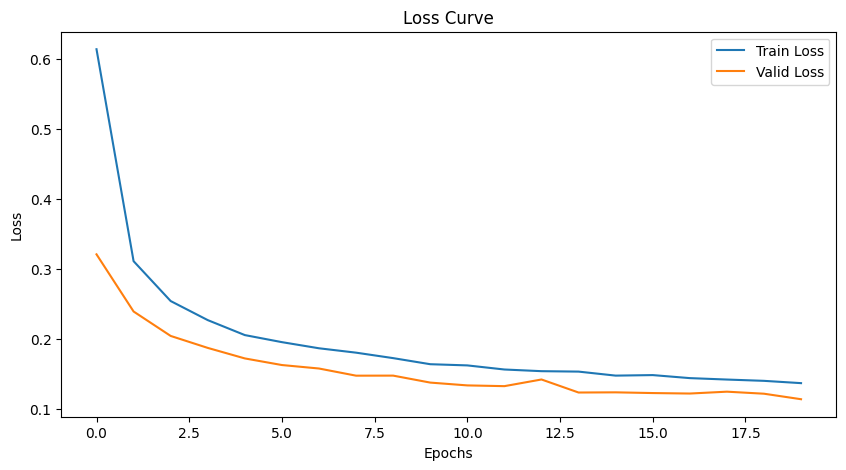

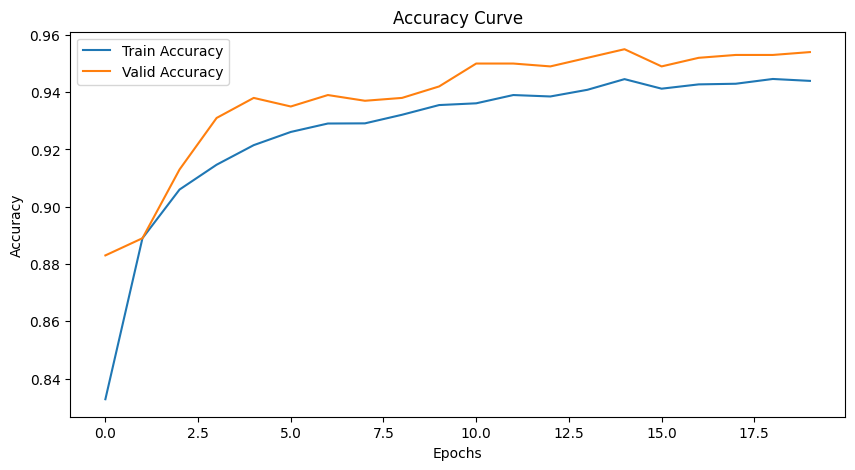

In [16]:
# Plot Loss Curve
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

# Plot Accuracy Curve
plt.figure(figsize=(10,5))
plt.plot(train_accs, label='Train Accuracy')
plt.plot(valid_accs, label='Valid Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')
plt.show()


## đánh giá

In [3]:
# Định nghĩa đường dẫn thư mục chứa dữ liệu
data_dir = "data/images"
train_data, valid_data, test_data = [], [], []
label_map = {}  # Mapping nhãn -> số


for label_idx, label in enumerate(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)
    if not os.path.isdir(label_path):
        continue
    
    # Lưu ánh xạ nhãn
    label_map[label] = label_idx
    
    # Lấy danh sách ảnh
    image_paths = glob(os.path.join(label_path, "*"))
    random.shuffle(image_paths)
    
    # Chia tập dữ liệu theo tỷ lệ 90:5:5
    ratito_1 = 0.9
    ratito_2 = 0.05

    total = len(image_paths)
    train_split = int(ratito_1 * total)
    valid_split = int((ratito_1+ratito_2) * total)

    train_data.extend([(p, label_idx) for p in image_paths[:train_split]])
    valid_data.extend([(p, label_idx) for p in image_paths[train_split:valid_split]])
    test_data.extend([(p, label_idx) for p in image_paths[valid_split:]])
    
# Kiểm tra số lượng mẫu mỗi tập
print(f"Train: {len(train_data)}, Valid: {len(valid_data)}, Test: {len(test_data)}")

# Hiển thị một số đường dẫn ảnh từ mỗi tập (kiểm tra kết quả)
print("Sample train images:", train_data[:3])
print("Sample valid images:", valid_data[:3])
print("Sample test images:", test_data[:3])
print("labels: ", label_map)

# Định nghĩa Dataset
class ImageDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Định nghĩa các phép biến đổi dữ liệu
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize ảnh về kích thước chuẩn
    transforms.ToTensor(), # Chuyển ảnh thành tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Chuẩn hóa theo ImageNet
])

# Tạo DataLoader
batch_size = 32 # số lượng mẫu được đưa vào mô hình trong 1 lần huấn luyện
test_loader = DataLoader(ImageDataset(test_data, transform), batch_size=batch_size, shuffle=False)

# Số lớp đầu ra
num_classes = len(label_map.keys())
print(num_classes)

Train: 18000, Valid: 1000, Test: 1000
Sample train images: [('data/images\\BENIGN\\680.png', 0), ('data/images\\BENIGN\\2051.png', 0), ('data/images\\BENIGN\\3595.png', 0)]
Sample valid images: [('data/images\\BENIGN\\1680.png', 0), ('data/images\\BENIGN\\37.png', 0), ('data/images\\BENIGN\\1966.png', 0)]
Sample test images: [('data/images\\BENIGN\\3146.png', 0), ('data/images\\BENIGN\\4033.png', 0), ('data/images\\BENIGN\\2583.png', 0)]
labels:  {'BENIGN': 0, 'Group1': 1, 'Group2': 2, 'Syn': 3}
4


In [4]:
# Kiểm tra thiết bị (GPU nếu có)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print("Using device:", device)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(label_map.keys()))  # Adjust output layer
model = model.to(device)
model.load_state_dict(torch.load("models/resnet50_finetuned.pth",  map_location=device))
print(len(label_map.keys()))

Using device: cpu
4


In [5]:
# Evaluate on test set
def evaluate_model(model, test_loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return y_true, y_pred

y_true, y_pred = evaluate_model(model, test_loader)

In [6]:
# Tính độ chính xác trên tập test
test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9110


In [7]:
# Classification report
print(classification_report(y_true, y_pred, target_names=label_map.keys()))

              precision    recall  f1-score   support

      BENIGN       0.91      0.99      0.95       250
      Group1       0.94      0.82      0.88       250
      Group2       0.82      0.91      0.86       250
         Syn       1.00      0.93      0.96       250

    accuracy                           0.91      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.91      0.91      1000



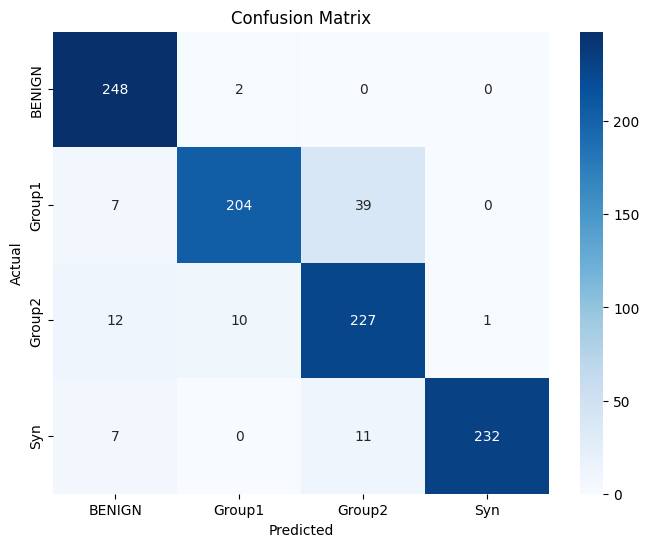

In [8]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


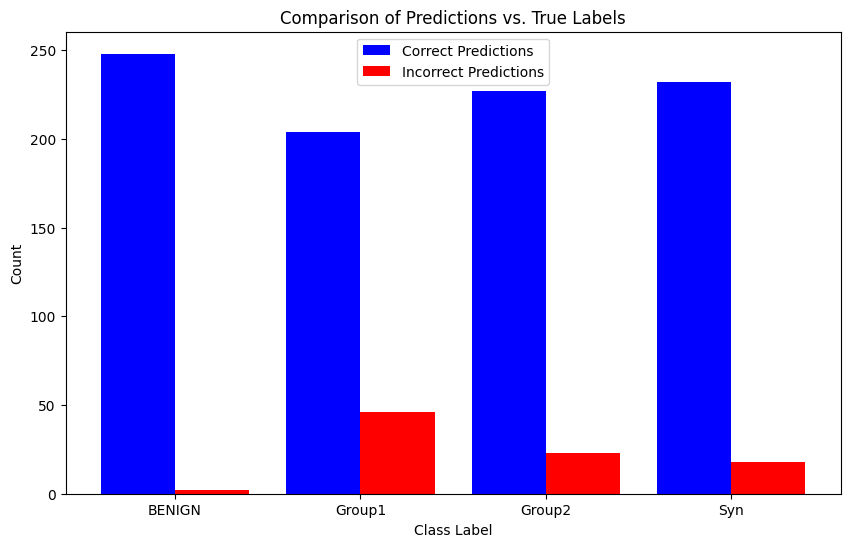

In [9]:
# Tạo DataFrame chứa nhãn thực tế và dự đoán
df = pd.DataFrame({"True Label": y_true, "Predicted Label": y_pred})

# Đếm số lượng dự đoán đúng và sai theo từng lớp
df["Correct"] = (df["True Label"] == df["Predicted Label"])  # True nếu dự đoán đúng

# Đếm số lượng đúng/sai theo từng lớp
correct_counts = df[df["Correct"]].groupby("True Label").size()
incorrect_counts = df[~df["Correct"]].groupby("True Label").size()

# Đảm bảo tất cả nhãn có trong bảng
correct_counts = correct_counts.reindex(range(num_classes), fill_value=0)
incorrect_counts = incorrect_counts.reindex(range(num_classes), fill_value=0)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.4
index = np.arange(num_classes)

plt.bar(index, correct_counts, bar_width, label="Correct Predictions", color="blue")
plt.bar(index + bar_width, incorrect_counts, bar_width, label="Incorrect Predictions", color="red")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Comparison of Predictions vs. True Labels")
plt.xticks(index + bar_width / 2, label_map.keys(), rotation=0)
plt.legend()
plt.show()

In [10]:
# Test individual images
def predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    print(f'Predicted label: {class_names[predicted.item()]}')


# Test individual images
def total_predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    return class_names[predicted.item()]

In [11]:
labels_list = list(label_map.keys())
print(labels_list)

# predict_image(model, "data/test/SYN/1.png", list(label_map.keys()))
# predict_image(model, "data/test/haa/rrr.png", list(label_map.keys()))

# predict_image(model, "data/cic_ddos_2019_images/Syn/4343.png", list(label_map.keys()))

# thống kê chi tiết tên nhãn dự đoán
for i in range(0, len(labels_list)):
    name_details_dict = {}

    for j in test_data:
        if j[1] == i:
            r = total_predict_image(model, f"{j[0]}", labels_list)
            if r in name_details_dict:
                name_details_dict[r] += 1
            else:
                name_details_dict[r] = 1

    print(f'Label: {labels_list[i]}', name_details_dict)



['BENIGN', 'Group1', 'Group2', 'Syn']
Label: BENIGN {'BENIGN': 248, 'Group1': 2}
Label: Group1 {'Group1': 204, 'Group2': 39, 'BENIGN': 7}
Label: Group2 {'Group2': 227, 'BENIGN': 12, 'Group1': 10, 'Syn': 1}
Label: Syn {'Syn': 232, 'BENIGN': 7, 'Group2': 11}


## Test với dữ liệu thực tế

In [ ]:
selected_columns = ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 
                    'Fwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 
                    'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 
                    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 
                    'Flow IAT Max', 'Flow IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Min', 
                    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 
                    'Bwd Header Length', 'Bwd Packets/s', 'Packet Length Max', 'FIN Flag Count', 'SYN Flag Count', 
                    'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 
                    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 
                    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 
                    'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Label']

len(selected_columns)

In [ ]:
df = pd.read_csv('temp/actual_data/test_syn.csv')
df = df[selected_columns]

In [ ]:

datadir = 'temp/actual_data/syn'
# datadir = 'test_image'
def convert(df_normalized_splited, label, num):
    width = 8
    height = 8
    size = 224
    upscale_factor_with = size // width 
    upscale_factor_height = size // height

    new_image_size = (width * upscale_factor_with, height * upscale_factor_height)

    os.makedirs(f"{datadir}", exist_ok=True)  # Tạo thư mục nếu chưa có

    i = 1
    for row in df_normalized_splited.values:
        # Chuyển đổi dòng thành ma trận ảnh ban đầu (8x8)
        image_array = np.array(row).reshape((width, height))
        image_array = np.nan_to_num(image_array)  # Thay thế giá trị NaN bằng 0

        # Phóng to mỗi pixel np.kron()
        upscale_matrix = np.ones((upscale_factor_with, upscale_factor_height))
        enlarged_image_array = np.kron(image_array, upscale_matrix)

        # Chuyển đổi sang ảnh
        image = Image.fromarray((enlarged_image_array * 255).astype(np.uint8))  # Chuyển sang RGB
        image = image.convert("RGB")

        # Lưu ảnh
        image = image.resize((size, size))
        image.save(f"{datadir}/{str(i)}.png")

        i += 1
        if i > num:
            break

def setup_to_convert(df_normalized, label):
    os.makedirs(f'{datadir}', exist_ok=True)

    # tổng số lượng ảnh train + valid + test của mỗi nhãn
    n = 500
    convert(df_normalized, label, num=n)

In [ ]:
## Load min và max từ file
with open("train_min_max.json", "r") as f:
    data = json.load(f)

mean = pd.Series(data["mean"])
std = pd.Series(data["std"])


df1 = df.drop(columns=['Label'])
df2 = df['Label']

# chuan hoa
data = df1.copy()
data.replace([-np.inf, np.inf], 0, inplace=True)
data.fillna(mean, inplace=True)

std.replace(0, 1, inplace=True) # 

data = (data - mean) / std

data.fillna(0, inplace=True)

data_df = np.log1p(data + 1)
data_scaled = pd.DataFrame(MinMaxScaler(feature_range=(0, 255)).fit_transform(data_df).astype(np.uint8))


# hop nhat
grouped =  pd.concat([df1, df2], ignore_index=True)
# Nhóm dữ liệu theo cột 'Label'
grouped = df.groupby('Label')

# Tạo dictionary để lưu các DataFrame tương ứng với từng nhãn
dfs = {label: group for label, group in grouped}

def process_label(label, df_label):
    df_drop_label = df_label.drop(columns=['Label'])
    data_normalized = df_drop_label
    setup_to_convert(data_normalized, label)

# Sử dụng ThreadPoolExecutor để chạy đa luồng với tối đa 5 luồng
with ThreadPoolExecutor(max_workers=3) as executor:
    futures = [executor.submit(process_label, label, df_label) for label, df_label in dfs.items()]

    # Đợi tất cả các task hoàn thành
    for future in futures:
        future.result()

print("Hoàn thành xử lý đa luồng!")

In [ ]:
# Kiểm tra thiết bị (GPU nếu có)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print("Using device:", device)

In [ ]:
label_map =  {'BENIGN': 0, 'LDAP': 1, 'MSSQL': 2, 'Portmap': 3, 'Syn': 4, 'UDP': 5, 'UDPLag': 6}

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

In [ ]:
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(label_map.keys()))  # Adjust output layer
model = model.to(device)
model.load_state_dict(torch.load("models/cic-ddos2019/resnet50_finetuned.pth",  map_location=torch.device('cpu')))
print(len(label_map.keys()))

In [ ]:
# Test individual images
def predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    print(f'Predicted label: {class_names[predicted.item()]}')


In [ ]:
labels_list = list(label_map.keys())
print(labels_list)

predict_image(model, "temp/actual_data/syn/2.png", list(label_map.keys()))
predict_image(model, "data/test_cic_ddos_2019_images/Syn/6.png", list(label_map.keys()))